# Alerta antecipado de picos de consumo do motor

**Pergunta do projeto:** dá para avisar, alguns segundos antes, que o consumo do motor vai entrar em *pico*, usando só o que o veículo já mediu? E qual é o custo desse aviso em alarmes falsos?

**Mapa do notebook: o que cada seção entrega**

| Seção | Pergunta | O que entrega |
|---|---|---|
| 1. Problema | O que é um pico e o que queremos prever? | Definição operacional de pico/episódio, descrição dos dados e aviso sobre a unidade |
| 2. Alerta antecipado | Dá para avisar antes do pico e a que custo? | Um alerta pronto para decisão: limiar escolhido por custo, probabilidades calibradas, antecedência (s) e alarmes falsos por hora, comparado a alertas simples |
| 3. Modelos de série temporal | Precisamos de um modelo mais complexo? | Comparação justa (mesmos folds, com intervalos de confiança) e a recomendação de qual modelo usar |
| 4. Regressão | Dá para prever o valor do consumo em t+5 melhor que "continua igual"? | Onde o modelo ganha e onde perde, uma correção testada e um intervalo de incerteza com cobertura medida |
| 5. Explicação | O que acontece antes de um pico? | Padrão descritivo dos sinais antes do pico e sua consistência entre modelo, regras (Apriori) e regimes (K-Means) |
| 6. Robustez | O resultado depende de escolhas arbitrárias? | Faixa de resultados em 9 definições de pico e uma validação alternativa |
| 7. Temperatura do óleo | A medição extra melhora o alerta? | Comparação pareada, com intervalo de confiança, nos 3 ensaios que a possuem |
| 8. Conclusões | O que se pode afirmar? | Resultados, limitações e próximos passos |

**Regras que valem em todo o notebook**
* Pico = consumo acima do percentil 90 **do próprio ensaio**; episódio = segundos consecutivos em pico.
* Teste separado **por ensaio** (*leave-one-experiment-out*). Limiares, calibração e hiperparâmetros são escolhidos **só com dados de treino**.
* Variáveis usam apenas `t` e o passado; o alvo olha $t_{+1} … t_{+H}$.
* Temperatura do óleo só nos 3 ensaios que a medem; $\pi_7$ (óleo ÷ arrefecimento) é derivada e entra sempre junto com a temperatura do óleo.
* Nada aqui é causal. A unidade do consumo **não foi validada** (ver seção 1).

In [13]:
import warnings, sys, platform, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import sklearn, torch
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.inspection import partial_dependence
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             mean_absolute_error)

warnings.filterwarnings("ignore")
SEED = 42
PEAK_Q = 0.90          # percentil que define pico (por ensaio)
H = 5                  # janela de antecipação (s)
WIN = 10               # janela de histórico para modelos de série temporal (s)
C_FA = 1.0             # custo de um segundo de alarme falso (unidade arbitrária)
C_MISS = 3.0           # custo de um segundo de pico não avisado (relativo ao alarme falso)
COST_RATIOS = [1.0, 3.0, 10.0]
N_BOOT = 400
RESULTS = {}           # números reportados (exportados em JSON no fim)

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (11, 5), "font.size": 13,
                     "axes.titlesize": 14, "axes.labelsize": 13, "legend.fontsize": 11,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 200, "display.max_columns", 40, "display.precision", 3)
C_BLUE, C_RED, C_GREEN, C_GRAY = "#1f77b4", "#d62728", "#2ca02c", "#7f7f7f"

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))
from motor.data_io import load_measurements
torch.set_num_threads(4)
print("python", platform.python_version(), "| sklearn", sklearn.__version__, "| torch", torch.__version__.split("+")[0])

python 3.14.2 | sklearn 1.9.1 | torch 2.14.1


## 1. O problema

> **Pergunta:** o que é um pico e o que queremos prever?  **Entrega:** a definição de pico/episódio usada em todo o trabalho, a descrição dos 4 ensaios e o aviso sobre a unidade do consumo.

**Por quê?** Um pico de consumo é um intervalo curto de alta demanda do motor. Saber *com alguns segundos de antecedência* que ele vem permite, em princípio, avisar o condutor ou um sistema de controle. O que importa é a **antecedência** do aviso e o **preço** em alarmes falsos, não só a acurácia.

**Definições.** Em cada ensaio, pico é o consumo acima do seu percentil 90; episódio é uma sequência de segundos consecutivos em pico. O alvo é `peak_next`: haverá pico em algum dos próximos `H = 5` segundos (o segundo atual não conta).

> ⚠️ **Unidade do consumo não validada.** O cabeçalho do CSV diz m³/s, mas os valores (0 a ~62) têm ordem de grandeza incompatível com a coluna de injeção (~1e-7, também em m³/s), e não há conversão nem referência do equipamento. Tudo é mostrado em **u.o.** (unidade original da coluna). Como o pico é definido por percentil dentro de cada ensaio, os resultados de alerta **não mudam** se o consumo for multiplicado por uma constante; só MAE e RMSE dependem da escala.

,limiar de pico (u.o.),episódios,duração mediana (s),horas de ensaio,prevalência alvo (5 s)
experiment,,,,,
D1T1A,32.720,53,3.0,0.551,0.169
D1T1B,33.875,47,2.0,0.493,0.172
D1T2,29.000,72,3.0,1.077,0.149
D2T1,30.060,63,2.0,0.473,0.196


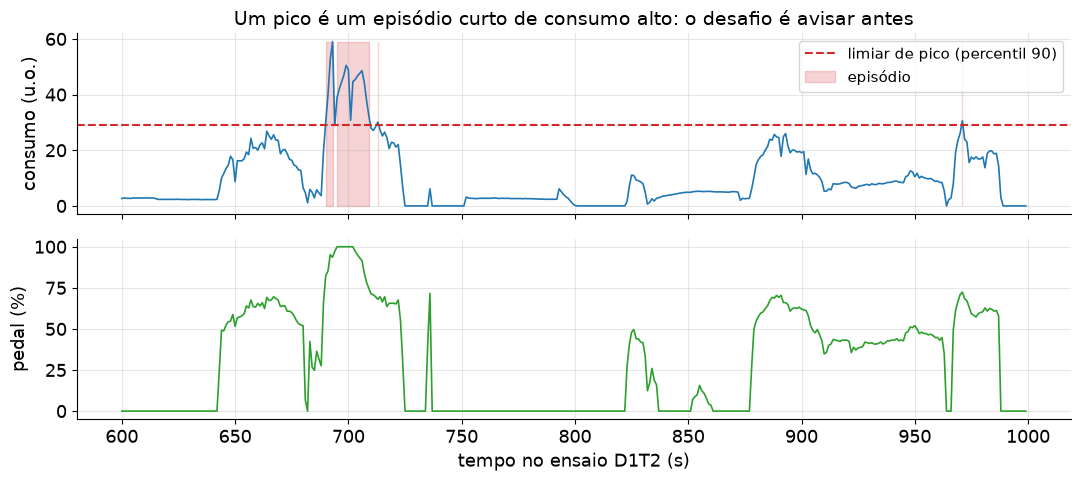

In [14]:
raw = load_measurements(ROOT / "Dados")
EXPS = list(raw["experiment"].unique())
EXPS_OIL = [e for e in EXPS if raw.loc[raw.experiment == e, "oil_temperature"].notna().any()]

SIGS = ["accelerator_position", "brake_position", "gear", "vehicle_speed", "engine_speed", "engine_torque"]
WIN_COLS = [f"{s}_l{k}" for s in SIGS for k in range(WIN - 1, -1, -1)]   # canal a canal, do mais antigo ao atual

def build_dataset(raw, q=PEAK_Q, horizon=H):
    parts = []
    for exp, g in raw.groupby("experiment", sort=False):
        g = g.sort_values("sample").reset_index(drop=True).copy()
        thr = g["fuel_consumption"].quantile(q)
        g["threshold"] = thr
        g["peak_now"] = (g["fuel_consumption"] > thr).astype(int)
        starts = g["peak_now"].eq(1) & g["peak_now"].shift().fillna(0).eq(0)
        g["episode"] = np.where(g["peak_now"] == 1, starts.cumsum(), 0)
        fut = pd.concat([g["peak_now"].shift(-k) for k in range(1, horizon + 1)], axis=1)
        g["peak_next"] = fut.max(axis=1).where(fut.notna().all(axis=1))
        for h in range(1, 6):
            g[f"y_{h}"] = g["fuel_consumption"].shift(-h)
        for v in ["accelerator_position", "engine_torque", "vehicle_speed", "engine_speed"]:
            g[f"{v}_d1"] = g[v].diff(1); g[f"{v}_d3"] = g[v].diff(3)
        for v in ["accelerator_position", "engine_torque"]:
            g[f"{v}_mean5"] = g[v].rolling(5).mean()
        g["brake_position_max5"] = g["brake_position"].rolling(5).max()
        g["cons_now"] = g["fuel_consumption"]
        g["cons_d1"] = g["fuel_consumption"].diff(1)
        g["cons_mean5"] = g["fuel_consumption"].rolling(5).mean()
        g["cons_max5"] = g["fuel_consumption"].rolling(5).max()
        g["pi_7"] = g["oil_temperature"] / g["coolant_temperature"]
        for s in SIGS:
            for k in range(1, WIN):
                g[f"{s}_l{k}"] = g[s].shift(k)
            g[f"{s}_l0"] = g[s]
        parts.append(g)
    df = pd.concat(parts, ignore_index=True)
    df["t_idx"] = df.groupby("experiment").cumcount()
    return df

GROUPS = {
    "velocidade": ["vehicle_speed", "vehicle_speed_d1", "vehicle_speed_d3"],
    "acelerador": ["accelerator_position", "accelerator_position_d1", "accelerator_position_d3", "accelerator_position_mean5"],
    "freio": ["brake_position", "brake_position_max5"],
    "marcha": ["gear"],
    "rotação": ["engine_speed", "engine_speed_d1", "engine_speed_d3"],
    "torque": ["engine_torque", "engine_torque_d1", "engine_torque_d3", "engine_torque_mean5"],
    "arrefecimento": ["coolant_temperature"],
    "temp. ambiente": ["ambient_temperature"],
}
CONS = ["cons_now", "cons_d1", "cons_mean5", "cons_max5"]
OIL = ["oil_temperature", "pi_7"]
OPER = [c for cols in GROUPS.values() for c in cols]

full = build_dataset(raw)
need = OPER + CONS + WIN_COLS + ["peak_next"] + [f"y_{h}" for h in range(1, 6)]
data = full.dropna(subset=need).reset_index(drop=True)
data["peak_next"] = data["peak_next"].astype(int)
ROWS = {e: data[data.experiment == e].reset_index(drop=True) for e in EXPS}

eps = full[full.peak_now == 1].groupby(["experiment", "episode"]).size().rename("dur").reset_index()
tab = pd.DataFrame({
    "limiar de pico (u.o.)": full.groupby("experiment")["threshold"].first(),
    "episódios": eps.groupby("experiment").size(),
    "duração mediana (s)": eps.groupby("experiment")["dur"].median(),
    "horas de ensaio": full.groupby("experiment").size() / 3600,
    "prevalência alvo (5 s)": data.groupby("experiment")["peak_next"].mean(),
})
display(tab)
RESULTS["n_linhas"] = int(len(data)); RESULTS["n_episodios"] = int(len(eps))
RESULTS["horas_total"] = float(len(data) / 3600)
RESULTS["prevalencia_alvo"] = float(data["peak_next"].mean())

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
g = full[full.experiment == "D1T2"].iloc[600:1000]
axes[0].plot(g.t_idx, g.fuel_consumption, color=C_BLUE, lw=1.2)
axes[0].axhline(g.threshold.iloc[0], color=C_RED, ls="--", label="limiar de pico (percentil 90)")
axes[0].fill_between(g.t_idx, 0, g.fuel_consumption.max(), where=g.peak_now == 1, color=C_RED, alpha=0.2, label="episódio")
axes[0].set_ylabel("consumo (u.o.)"); axes[0].legend(loc="upper right")
axes[0].set_title("Um pico é um episódio curto de consumo alto: o desafio é avisar antes")
axes[1].plot(g.t_idx, g.accelerator_position, color=C_GREEN, lw=1.2); axes[1].set_ylabel("pedal (%)"); axes[1].set_xlabel("tempo no ensaio D1T2 (s)")
plt.tight_layout(); plt.show()

### Infraestrutura comum

Folds por ensaio, métricas, regras do Apriori (usadas como "alerta simples" de comparação) e *bootstrap por episódios* (reamostra blocos de segundos ligados a cada episódio, não segundos soltos, porque segundos vizinhos são quase iguais).

In [15]:
def folds(exps, df=None):
    df = data if df is None else df
    for test in exps:
        yield test, df[df.experiment.isin([e for e in exps if e != test])].reset_index(drop=True), \
              df[df.experiment == test].reset_index(drop=True)

def hgb_clf(**kw):
    return HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=200, random_state=SEED, **kw)

def ap(y, s): return average_precision_score(y, s)

def onset_ap(te, s, col="peak_next"):
    m = te["peak_now"].to_numpy() == 0
    return ap(te[col].to_numpy()[m], np.asarray(s)[m])

# ---------- regras (Apriori) ----------
from mlxtend.frequent_patterns import apriori, association_rules
ITEM_VARS = ["vehicle_speed", "accelerator_position", "engine_speed", "engine_torque"]
GEARS = sorted(full["gear"].dropna().unique())

def fit_bins(train):
    ed = {v: np.unique(np.quantile(train[v], [1 / 3, 2 / 3])) for v in ITEM_VARS}
    ed["torque_d3"] = np.quantile(train["engine_torque_d3"], [0.15, 0.85])
    ed["pedal_d3"] = np.quantile(train["accelerator_position_d3"], [0.15, 0.85])
    return ed

def to_items(df, ed):
    short = {"vehicle_speed": "vel", "accelerator_position": "pedal", "engine_speed": "rot", "engine_torque": "torque"}
    items = {}
    for v in ITEM_VARS:
        e = ed[v]; lvl = np.searchsorted(e, df[v].to_numpy(), side="left"); c = [f"{x:.4g}" for x in e]
        names = ([f"{short[v]}≤{c[0]}", f"{short[v]}>{c[0]}"] if len(c) == 1 else
                 [f"{short[v]}≤{c[0]}", f"{short[v]}∈({c[0]},{c[1]}]", f"{short[v]}>{c[1]}"])
        for k, n in enumerate(names): items[n] = lvl == k
    items["freio_ligado"] = (df["brake_position"] > 0).to_numpy()
    items["freio_desligado"] = (df["brake_position"] <= 0).to_numpy()
    for gv in GEARS: items[f"marcha={int(gv)}"] = (df["gear"] == gv).to_numpy()
    items["pedal_subindo"] = (df["accelerator_position_d3"] >= ed["pedal_d3"][1]).to_numpy()
    items["pedal_descendo"] = (df["accelerator_position_d3"] <= ed["pedal_d3"][0]).to_numpy()
    items["torque_subindo"] = (df["engine_torque_d3"] >= ed["torque_d3"][1]).to_numpy()
    items["torque_descendo"] = (df["engine_torque_d3"] <= ed["torque_d3"][0]).to_numpy()
    return pd.DataFrame(items, index=df.index)

def best_rule(train, min_support=0.03):
    ed = fit_bins(train); X = to_items(train, ed); X["PICO"] = train["peak_next"].to_numpy().astype(bool)
    fi = apriori(X, min_support=0.02, use_colnames=True, max_len=3)
    ru = association_rules(fi, num_itemsets=len(X), metric="lift", min_threshold=1.2)
    ru = ru[ru["consequents"].apply(lambda s: s == frozenset({"PICO"}))]
    ru = ru[ru.support >= min_support].sort_values(["lift", "support"], ascending=False)
    top = ru.iloc[0]
    return ed, sorted(top["antecedents"]), float(top["lift"]), float(top["confidence"])

def rule_active(df, ed, ante): return to_items(df, ed)[ante].all(axis=1).to_numpy()

# ---------- bootstrap por episódios ----------
def episode_blocks(te):
    """Cada bloco = segundos anteriores a um episódio + o episódio; sobra final é um bloco."""
    leave = (te["peak_now"].shift(1).fillna(0) == 1) & (te["peak_now"] == 0)
    bid = leave.cumsum().to_numpy()
    return [np.where(bid == b)[0] for b in np.unique(bid)]

BLOCKS = {e: episode_blocks(ROWS[e]) for e in EXPS}

def boot_metric(scores, metric, exps, B=N_BOOT, seed=SEED):
    """scores: {nome: {ensaio: array}}. metric(te, s) -> float. Retorna amostras (B) da média entre ensaios."""
    rng = np.random.default_rng(seed)
    out = {n: np.empty(B) for n in scores}
    for b in range(B):
        acc = {n: [] for n in scores}
        for e in exps:
            bl = BLOCKS[e]; pick = rng.integers(0, len(bl), len(bl))
            idx = np.concatenate([bl[i] for i in pick]); te = ROWS[e].iloc[idx]
            for n in scores:
                try: acc[n].append(metric(te, scores[n][e][idx]))
                except ValueError: acc[n].append(np.nan)
        for n in scores: out[n][b] = np.nanmean(acc[n])
    return out

def ci(x, lo=2.5, hi=97.5): return float(np.percentile(x, lo)), float(np.percentile(x, hi))

## 2. Alerta antecipado: do modelo a um sistema de decisão

> **Pergunta:** dá para avisar antes do pico e a que custo em alarmes falsos?  **Entrega:** um alerta pronto para decisão (limiar escolhido por custo, probabilidades calibradas), medido em *segundos de antecedência* e *alarmes falsos por hora*, e comparado a dois alertas simples.

**Modelo.** Gradient boosting (histograma) com as condições operacionais (`OPER`: pedais, marcha, rotação, torque, velocidade, temperaturas e suas variações recentes). **Não** usa o consumo.

**Do modelo ao alerta, sem espiar o teste.** Para cada ensaio de teste:
1. Gera-se, nos ensaios de treino, probabilidades *fora da amostra* (validação interna por ensaio).
2. Ajusta-se um **calibrador isotônico** sobre elas, para que "0,6" signifique ≈ 60%.
3. Escolhe-se o **limiar de alerta** que minimiza o custo `C_FA·(segundos de alarme falso) + C_MISS·(segundos de pico não avisados)` nessas probabilidades internas.
4. Só então aplica-se tudo ao ensaio de teste.

Os custos são parâmetros: usamos `C_MISS = 3` como caso principal e mostramos 1 e 10 também. Comparamos com dois alertas simples: **persistência** (alerta enquanto já está em pico) e **regra única** (a melhor regra do Apriori, minerada no treino).

In [16]:
THR_GRID = np.linspace(0.02, 0.9, 45)

def cost_curve(y, p, r):
    pred = p[:, None] >= THR_GRID[None, :]
    fp = (pred & (y[:, None] == 0)).sum(0); fn = ((~pred) & (y[:, None] == 1)).sum(0)
    return C_FA * fp + r * fn

def fit_alert(train, test, cols):
    """Treino → probabilidades internas (OOF por ensaio) → calibração → limiares; aplica ao teste."""
    tr_exps = list(train.experiment.unique()); oof = np.empty(len(train))
    for e in tr_exps:
        m = hgb_clf().fit(train.loc[train.experiment != e, cols], train.loc[train.experiment != e, "peak_next"])
        oof[(train.experiment == e).to_numpy()] = m.predict_proba(train.loc[train.experiment == e, cols])[:, 1]
    y = train["peak_next"].to_numpy()
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(oof, y)
    oof_cal = iso.predict(oof)
    thr, curves = {}, {}
    for r in COST_RATIOS:
        c = cost_curve(y, oof_cal, r); curves[r] = c / (r * y.sum())     # relativo a "nunca alertar"
        thr[r] = float(THR_GRID[int(np.argmin(c))])
    final = hgb_clf().fit(train[cols], y)
    p_raw = final.predict_proba(test[cols])[:, 1]
    return {"p_raw": p_raw, "p_cal": iso.predict(p_raw), "thr": thr, "curves": curves, "model": final,
            "prev_train": float(y.mean())}

def alert_eval(te, alert):
    """Métricas de alerta: precisão/recall por segundo, alarmes falsos por hora, antecedência por episódio."""
    alert = np.asarray(alert).astype(bool); y = te["peak_next"].to_numpy()
    tp = (alert & (y == 1)).sum()
    prec = tp / alert.sum() if alert.sum() else np.nan
    rec = tp / y.sum()
    runs = np.flatnonzero(np.diff(np.r_[0, alert.astype(int), 0]) != 0).reshape(-1, 2)
    fa = sum(1 for a, b in runs if y[a:b].sum() == 0)
    leads, n_iso, n_ant = [], 0, 0
    pn = te["peak_now"].to_numpy()
    starts = np.flatnonzero((pn == 1) & (np.r_[0, pn[:-1]] == 0))
    for s in starts:
        if s < H or pn[s - H:s].any(): continue          # só episódios isolados (sem pico nos H s anteriores)
        n_iso += 1
        w = np.flatnonzero(alert[s - H:s])
        if len(w): n_ant += 1; leads.append(H - w[0])
    return {"precisão": prec, "recall": rec, "alarmes falsos/h": fa / (len(te) / 3600),
            "episódios isolados": n_iso, "antecipados": n_ant / max(n_iso, 1),
            "antecedência mediana (s)": float(np.median(leads)) if leads else np.nan, "_leads": leads}

ALERT = {}      # (ensaio de teste, conjunto de variáveis) -> resultado de fit_alert
for test, tr, te in folds(EXPS):
    ALERT[(test, "OPER")] = fit_alert(tr, te, OPER)
    ALERT[(test, "regra")] = None
    ed, ante, lift, conf = best_rule(tr)
    ALERT[(test, "regra")] = {"active": rule_active(te, ed, ante), "ante": ante, "lift": lift, "conf": conf}
for t in EXPS: print(t, "→ regra do treino:", " ∧ ".join(ALERT[(t, "regra")]["ante"]),
                     f"(lift {ALERT[(t, 'regra')]['lift']:.2f})", "| limiares:", ALERT[(t, "OPER")]["thr"])

D1T1A → regra do treino: rot>19.39 ∧ torque_subindo (lift 3.96) | limiares: {1.0: 0.48000000000000004, 3.0: 0.24, 10.0: 0.08}
D1T1B → regra do treino: rot>19.3 ∧ torque_subindo (lift 4.10) | limiares: {1.0: 0.46, 3.0: 0.24, 10.0: 0.08}
D1T2 → regra do treino: rot>19.56 ∧ torque_subindo (lift 4.00) | limiares: {1.0: 0.5, 3.0: 0.22, 10.0: 0.08}
D2T1 → regra do treino: rot>19.1 ∧ torque_subindo (lift 4.29) | limiares: {1.0: 0.44, 3.0: 0.24, 10.0: 0.1}


In [17]:
rows = []
for test in EXPS:
    te = ROWS[test]; a = ALERT[(test, "OPER")]; y = te["peak_next"].to_numpy()
    rows.append({"teste": test, "método": "persistência", **alert_eval(te, te["peak_now"].to_numpy() == 1)})
    rows.append({"teste": test, "método": "regra única (Apriori)", **alert_eval(te, ALERT[(test, "regra")]["active"])})
    for r in COST_RATIOS:
        rows.append({"teste": test, "método": f"modelo, C_MISS={r:g}", **alert_eval(te, a["p_cal"] >= a["thr"][r])})
al = pd.DataFrame(rows)
cols_show = ["precisão", "recall", "alarmes falsos/h", "antecipados", "antecedência mediana (s)"]
al_mean = al.groupby("método", sort=False)[cols_show].mean()
display(Markdown("**Média dos 4 ensaios de teste (cada ensaio é teste uma vez)**"))
display(al_mean)
display(Markdown("**Por ensaio, modelo com C_MISS = 3**"))
display(al[al["método"] == "modelo, C_MISS=3"].set_index("teste")[cols_show + ["episódios isolados"]])

main = al_mean.loc["modelo, C_MISS=3"]; rule_m = al_mean.loc["regra única (Apriori)"]; pers_m = al_mean.loc["persistência"]
RESULTS["alerta"] = {k: {c: float(v) for c, v in al_mean.loc[k].items()} for k in al_mean.index}
RESULTS["alerta_por_ensaio"] = {t: {c: float(v) for c, v in al[(al.teste == t) & (al["método"] == "modelo, C_MISS=3")].iloc[0][cols_show].items()} for t in EXPS}

**Média dos 4 ensaios de teste (cada ensaio é teste uma vez)**

,precisão,recall,alarmes falsos/h,antecipados,antecedência mediana (s)
método,,,,,
persistência,0.887,0.526,17.097,0.000,NaN
regra única (Apriori),0.688,0.250,38.318,0.631,2.625
"modelo, C_MISS=1",0.778,0.683,39.703,0.683,2.750
"modelo, C_MISS=3",0.663,0.822,55.966,0.920,3.250
"modelo, C_MISS=10",0.489,0.927,107.080,1.000,4.750


**Por ensaio, modelo com C_MISS = 3**

,precisão,recall,alarmes falsos/h,antecipados,antecedência mediana (s),episódios isolados
teste,,,,,,
D1T1A,0.621,0.855,56.650,1.000,3.0,23
D1T1B,0.579,0.921,57.208,1.000,4.0,22
D1T2,0.584,0.837,80.166,0.906,3.0,32
D2T1,0.868,0.674,29.840,0.773,3.0,22


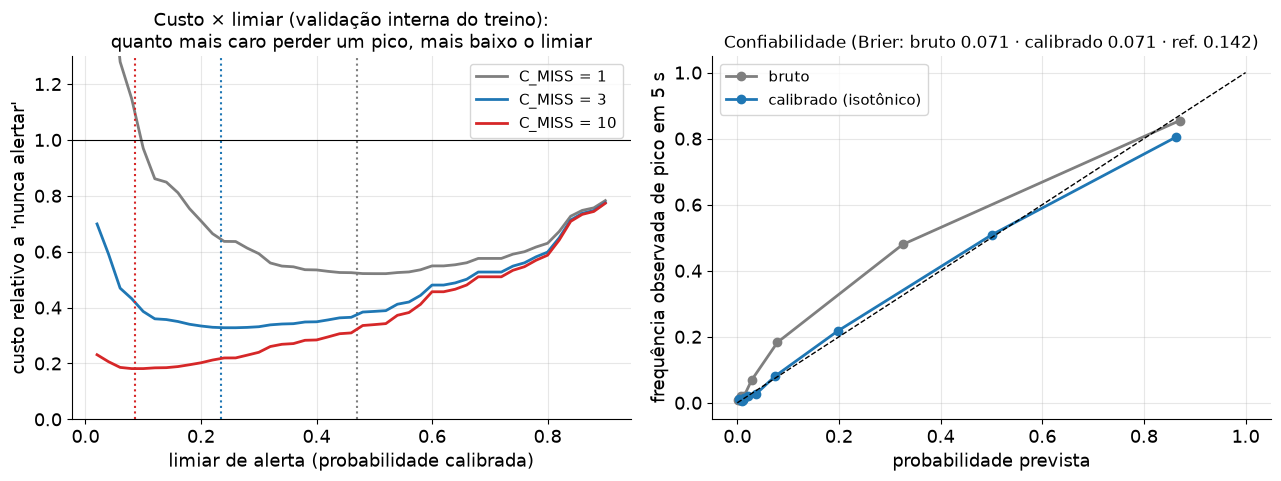

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# (a) curvas de custo × limiar (média dos folds)
for r, col in zip(COST_RATIOS, [C_GRAY, C_BLUE, C_RED]):
    cur = np.mean([ALERT[(t, "OPER")]["curves"][r] for t in EXPS], axis=0)
    axes[0].plot(THR_GRID, cur, color=col, lw=2, label=f"C_MISS = {r:g}")
    thr_m = np.mean([ALERT[(t, "OPER")]["thr"][r] for t in EXPS])
    axes[0].axvline(thr_m, color=col, ls=":", lw=1.5)
axes[0].axhline(1, color="k", lw=0.8); axes[0].set_ylim(0, 1.3)
axes[0].set_xlabel("limiar de alerta (probabilidade calibrada)"); axes[0].set_ylabel("custo relativo a 'nunca alertar'")
axes[0].set_title("Custo × limiar (validação interna do treino):\nquanto mais caro perder um pico, mais baixo o limiar", fontsize=13)
axes[0].legend()
# (b) confiabilidade
pr = np.concatenate([ALERT[(t, "OPER")]["p_raw"] for t in EXPS]); pc = np.concatenate([ALERT[(t, "OPER")]["p_cal"] for t in EXPS])
yy = np.concatenate([ROWS[t]["peak_next"].to_numpy() for t in EXPS])
for p, lab, col in [(pr, "bruto", C_GRAY), (pc, "calibrado (isotônico)", C_BLUE)]:
    q = pd.qcut(p, 10, duplicates="drop"); d = pd.DataFrame({"p": p, "y": yy, "q": q}).groupby("q", observed=True).agg(p=("p", "mean"), y=("y", "mean"))
    axes[1].plot(d.p, d.y, "o-", color=col, label=lab, lw=2)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("probabilidade prevista"); axes[1].set_ylabel("frequência observada de pico em 5 s")
brier_raw = np.mean([brier_score_loss(ROWS[t]["peak_next"], ALERT[(t, "OPER")]["p_raw"]) for t in EXPS])
brier_cal = np.mean([brier_score_loss(ROWS[t]["peak_next"], ALERT[(t, "OPER")]["p_cal"]) for t in EXPS])
brier_ref = np.mean([brier_score_loss(ROWS[t]["peak_next"], np.full(len(ROWS[t]), ALERT[(t, 'OPER')]["prev_train"])) for t in EXPS])
axes[1].set_title(f"Confiabilidade (Brier: bruto {brier_raw:.3f} · calibrado {brier_cal:.3f} · ref. {brier_ref:.3f})", fontsize=12)
axes[1].legend(); plt.tight_layout(); plt.show()
RESULTS["brier"] = {"bruto": float(brier_raw), "calibrado": float(brier_cal), "referencia_prevalencia": float(brier_ref)}

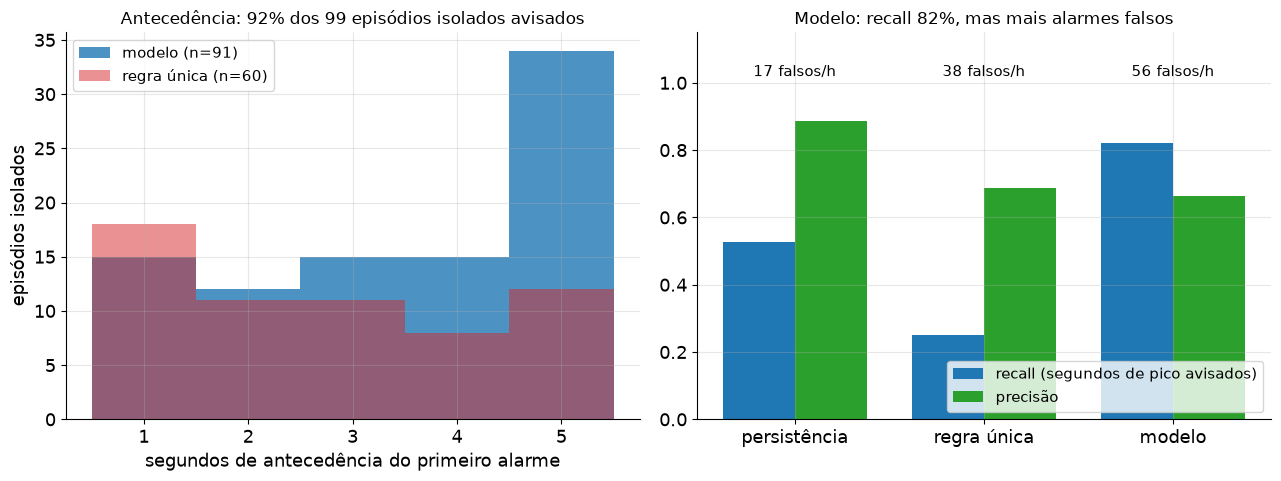

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
leads_m = np.concatenate([alert_eval(ROWS[t], ALERT[(t, "OPER")]["p_cal"] >= ALERT[(t, "OPER")]["thr"][C_MISS])["_leads"] for t in EXPS])
leads_r = np.concatenate([alert_eval(ROWS[t], ALERT[(t, "regra")]["active"])["_leads"] for t in EXPS])
n_iso = int(sum(alert_eval(ROWS[t], ALERT[(t, "OPER")]["p_cal"] >= 0.5)["episódios isolados"] for t in EXPS))
bins = np.arange(0.5, H + 1.5)
axes[0].hist(leads_m, bins=bins, alpha=0.8, color=C_BLUE, label=f"modelo (n={len(leads_m)})")
axes[0].hist(leads_r, bins=bins, alpha=0.5, color=C_RED, label=f"regra única (n={len(leads_r)})")
axes[0].set_xlabel("segundos de antecedência do primeiro alarme"); axes[0].set_ylabel("episódios isolados")
axes[0].set_title(f"Antecedência: {main['antecipados']*100:.0f}% dos {n_iso} episódios isolados avisados", fontsize=12)
axes[0].legend()
meth = ["persistência", "regra única (Apriori)", "modelo, C_MISS=3"]
x = np.arange(3); w = 0.38
axes[1].bar(x - w / 2, [al_mean.loc[m, "recall"] for m in meth], w, color=C_BLUE, label="recall (segundos de pico avisados)")
axes[1].bar(x + w / 2, [al_mean.loc[m, "precisão"] for m in meth], w, color=C_GREEN, label="precisão")
for i, m in enumerate(meth):
    axes[1].text(i, 1.02, f"{al_mean.loc[m, 'alarmes falsos/h']:.0f} falsos/h", ha="center", fontsize=11)
axes[1].set_xticks(x); axes[1].set_xticklabels(["persistência", "regra única", "modelo"]); axes[1].set_ylim(0, 1.15)
axes[1].set_title(f"Modelo: recall {main['recall']*100:.0f}%, mas mais alarmes falsos", fontsize=12); axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

**O que concluímos.** O alerta do modelo é comparado, com o mesmo teste por ensaio, a dois alertas simples. A persistência só acusa quando o pico já começou, então tem antecedência zero por construção. A regra única é um alerta simples de "rotação alta e torque subindo", mas tem recall baixo. O modelo paga o ganho de recall e de antecedência com **mais alarmes falsos por hora que a persistência** (veja a tabela). Esse número depende do custo escolhido: **o limiar é uma decisão de negócio**, não um número mágico do modelo. Ressalva: os custos são por segundo e arbitrários; um custo real deveria vir da aplicação.

## 3. Qual modelo de série temporal? (mesmos folds, mesmas linhas)

> **Pergunta:** vale usar um modelo mais complexo (rede neural) em vez de um mais simples?  **Entrega:** comparação justa entre quatro modelos, com intervalos de confiança, e a recomendação de qual usar.

Quatro modelos recebem as **últimas 10 s** de seis sinais (pedal, freio, marcha, velocidade, rotação, torque), além da persistência:

| Modelo | Entrada |
|---|---|
| Regressão logística | janela de 10 s achatada (60 valores) |
| Gradient boosting (janela) | janela de 10 s achatada |
| Gradient boosting (`OPER`) | variáveis construídas à mão (variações, médias móveis, temperaturas) |
| Rede 1D-CNN pequena | janela 6 canais × 10 s; 2 camadas convolucionais, 3 sementes, 30 épocas fixas (sem ajuste) |

Métrica: PR-AUC (sem limiar). Mostramos também a PR-AUC só nas linhas **fora de pico**, que é onde a antecipação tem valor.

In [20]:
import torch.nn as nn

class SmallCNN(nn.Module):
    def __init__(self, c=len(SIGS)):
        super().__init__()
        self.net = nn.Sequential(nn.Conv1d(c, 16, 3, padding=1), nn.ReLU(), nn.Conv1d(16, 16, 3, padding=1), nn.ReLU(),
                                 nn.AdaptiveMaxPool1d(1), nn.Flatten(), nn.Linear(16, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

def to_tensor(df):
    return df[WIN_COLS].to_numpy().reshape(len(df), len(SIGS), WIN).astype("float32")

def fit_cnn(train, test, seeds=(0, 1, 2), epochs=30):
    Xtr, Xte = to_tensor(train), to_tensor(test)
    mu = Xtr.mean(axis=(0, 2), keepdims=True); sd = Xtr.std(axis=(0, 2), keepdims=True) + 1e-6
    Xtr, Xte = (Xtr - mu) / sd, (Xte - mu) / sd
    ytr = torch.tensor(train["peak_next"].to_numpy(), dtype=torch.float32)
    pw = torch.tensor(float((1 - ytr.mean()) / ytr.mean()) ** 0.5)
    ps = []
    for sd_ in seeds:
        torch.manual_seed(sd_); m = SmallCNN(); opt = torch.optim.Adam(m.parameters(), lr=2e-3, weight_decay=1e-4)
        lossf = nn.BCEWithLogitsLoss(pos_weight=pw); X = torch.tensor(Xtr)
        for _ in range(epochs):
            perm = torch.randperm(len(X))
            for i in range(0, len(X), 256):
                b = perm[i:i + 256]; opt.zero_grad(); lossf(m(X[b]), ytr[b]).backward(); opt.step()
        m.eval()
        with torch.no_grad(): ps.append(torch.sigmoid(m(torch.tensor(Xte))).numpy())
    return np.mean(ps, axis=0)

SCORES = {"persistência": {}, "regra única": {}, "LogReg (janela)": {}, "HGB (janela)": {},
          "HGB (OPER)": {}, "1D-CNN (janela)": {}}
t0 = time.time()
for test, tr, te in folds(EXPS):
    SCORES["persistência"][test] = te["peak_now"].to_numpy().astype(float)
    SCORES["regra única"][test] = ALERT[(test, "regra")]["active"].astype(float)
    SCORES["HGB (OPER)"][test] = ALERT[(test, "OPER")]["p_raw"]
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(tr[WIN_COLS], tr["peak_next"])
    SCORES["LogReg (janela)"][test] = lr.predict_proba(te[WIN_COLS])[:, 1]
    SCORES["HGB (janela)"][test] = hgb_clf().fit(tr[WIN_COLS], tr["peak_next"]).predict_proba(te[WIN_COLS])[:, 1]
    SCORES["1D-CNN (janela)"][test] = fit_cnn(tr, te)
print(f"tempo: {time.time() - t0:.0f} s")

rows = []
for name, d in SCORES.items():
    for t in EXPS:
        te = ROWS[t]; s = d[t]
        rows.append({"modelo": name, "teste": t, "PR-AUC": ap(te["peak_next"], s), "PR-AUC início": onset_ap(te, s),
                     "ROC-AUC": roc_auc_score(te["peak_next"], s)})
ts = pd.DataFrame(rows)
ts_mean = ts.groupby("modelo", sort=False)[["PR-AUC", "PR-AUC início", "ROC-AUC"]].mean()
display(ts_mean)
display(ts.pivot_table(index="modelo", columns="teste", values="PR-AUC início", sort=False))
RESULTS["modelos_serie"] = {k: {c: float(v) for c, v in ts_mean.loc[k].items()} for k in ts_mean.index}
RESULTS["modelos_serie_inicio_por_ensaio"] = {m: {t: float(v) for t, v in ts[ts.modelo == m].set_index("teste")["PR-AUC início"].items()} for m in ts_mean.index}

tempo: 17 s


,PR-AUC,PR-AUC início,ROC-AUC
modelo,,,
persistência,0.550,0.091,0.756
regra única,0.303,0.156,0.613
LogReg (janela),0.837,0.563,0.940
HGB (janela),0.828,0.550,0.936
HGB (OPER),0.837,0.589,0.944
1D-CNN (janela),0.830,0.528,0.939


teste,D1T1A,D1T1B,D1T2,D2T1
modelo,,,,
persistência,0.088,0.093,0.065,0.120
regra única,0.192,0.157,0.099,0.177
LogReg (janela),0.544,0.518,0.493,0.698
HGB (janela),0.522,0.545,0.463,0.670
HGB (OPER),0.581,0.602,0.453,0.717
1D-CNN (janela),0.534,0.457,0.448,0.672


,PR-AUC,IC95% PR-AUC,PR-AUC início,IC95% início
HGB (OPER),0.837,"[0.793, 0.867]",0.589,"[0.532, 0.656]"
HGB (janela),0.828,"[0.784, 0.858]",0.55,"[0.487, 0.625]"
LogReg (janela),0.837,"[0.791, 0.866]",0.563,"[0.506, 0.634]"
1D-CNN (janela),0.83,"[0.781, 0.860]",0.528,"[0.464, 0.605]"
persistência,0.55,"[0.494, 0.599]",0.091,"[0.076, 0.126]"


Δ início (CNN − HGB OPER): -0.057  IC95% [-0.097, -0.023]
Δ início (HGB janela − HGB OPER): -0.038  IC95% [-0.066, -0.007]


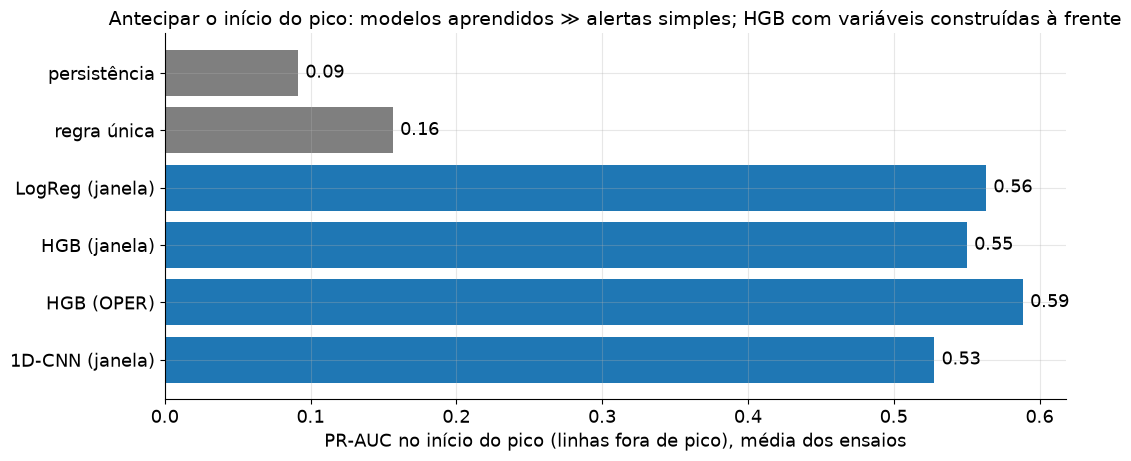

In [21]:
# IC 95% por bootstrap de episódios; diferença pareada para o melhor modelo
names = ["HGB (OPER)", "HGB (janela)", "LogReg (janela)", "1D-CNN (janela)", "persistência"]
bs = boot_metric({n: SCORES[n] for n in names}, lambda te, s: ap(te["peak_next"], s), EXPS)
bs_on = boot_metric({n: SCORES[n] for n in names}, lambda te, s: onset_ap(te, s), EXPS)
ci_tab = pd.DataFrame({n: {"PR-AUC": ts_mean.loc[n, "PR-AUC"], "IC95% PR-AUC": f"[{ci(bs[n])[0]:.3f}, {ci(bs[n])[1]:.3f}]",
                           "PR-AUC início": ts_mean.loc[n, "PR-AUC início"], "IC95% início": f"[{ci(bs_on[n])[0]:.3f}, {ci(bs_on[n])[1]:.3f}]"} for n in names}).T
display(ci_tab)
d_cnn_hgb = bs_on["1D-CNN (janela)"] - bs_on["HGB (OPER)"]
d_win_hgb = bs_on["HGB (janela)"] - bs_on["HGB (OPER)"]
print(f"Δ início (CNN − HGB OPER): {d_cnn_hgb.mean():+.3f}  IC95% [{ci(d_cnn_hgb)[0]:+.3f}, {ci(d_cnn_hgb)[1]:+.3f}]")
print(f"Δ início (HGB janela − HGB OPER): {d_win_hgb.mean():+.3f}  IC95% [{ci(d_win_hgb)[0]:+.3f}, {ci(d_win_hgb)[1]:+.3f}]")
RESULTS["ic_modelos"] = {n: {"PR-AUC": [*ci(bs[n])], "inicio": [*ci(bs_on[n])]} for n in names}
RESULTS["delta_cnn_vs_hgb_inicio"] = [float(d_cnn_hgb.mean()), *ci(d_cnn_hgb)]
RESULTS["delta_janela_vs_hgb_inicio"] = [float(d_win_hgb.mean()), *ci(d_win_hgb)]

order = ["persistência", "regra única", "LogReg (janela)", "HGB (janela)", "HGB (OPER)", "1D-CNN (janela)"]
fig, ax = plt.subplots(figsize=(11, 4.8))
y_ = np.arange(len(order))
ax.barh(y_, [ts_mean.loc[n, "PR-AUC início"] for n in order], color=[C_GRAY if n in ("persistência", "regra única") else C_BLUE for n in order])
for i, n in enumerate(order): ax.text(ts_mean.loc[n, "PR-AUC início"] + 0.005, i, f"{ts_mean.loc[n, 'PR-AUC início']:.2f}", va="center")
ax.set_yticks(y_); ax.set_yticklabels(order); ax.invert_yaxis(); ax.set_xlabel("PR-AUC no início do pico (linhas fora de pico), média dos ensaios")
ax.set_title("Antecipar o início do pico: modelos aprendidos ≫ alertas simples; HGB com variáveis construídas à frente")
plt.tight_layout(); plt.show()

In [22]:
d_lr = bs_on["LogReg (janela)"] - bs_on["HGB (OPER)"]
display(Markdown(f"""**O que concluímos.** Todos os modelos aprendidos superam de longe a persistência e a regra única. Entre eles, a diferença é pequena em valor absoluto, mas medida em episódios: CNN − HGB `OPER` = {d_cnn_hgb.mean():+.3f} (IC95% [{ci(d_cnn_hgb)[0]:+.3f}, {ci(d_cnn_hgb)[1]:+.3f}]), gradient boosting em janela − `OPER` = {d_win_hgb.mean():+.3f} ([{ci(d_win_hgb)[0]:+.3f}, {ci(d_win_hgb)[1]:+.3f}]) e regressão logística − `OPER` = {d_lr.mean():+.3f} ([{ci(d_lr)[0]:+.3f}, {ci(d_lr)[1]:+.3f}]). Onde o intervalo exclui zero, o gradient boosting com variáveis construídas à mão fica à frente; onde inclui, não há evidência de diferença. **A rede 1D-CNN não ganhou**: com cerca de 9 mil linhas e 4 ensaios, a engenharia de variáveis (variações, médias móveis) rendeu mais que a aprendizagem automática de características. Isso é um resultado, não uma falha: um modelo mais simples basta."""))
RESULTS["delta_logreg_vs_hgb_inicio"] = [float(d_lr.mean()), *ci(d_lr)]

**O que concluímos.** Todos os modelos aprendidos superam de longe a persistência e a regra única. Entre eles, a diferença é pequena em valor absoluto, mas medida em episódios: CNN − HGB `OPER` = -0.057 (IC95% [-0.097, -0.023]), gradient boosting em janela − `OPER` = -0.038 ([-0.066, -0.007]) e regressão logística − `OPER` = -0.025 ([-0.063, +0.010]). Onde o intervalo exclui zero, o gradient boosting com variáveis construídas à mão fica à frente; onde inclui, não há evidência de diferença. **A rede 1D-CNN não ganhou**: com cerca de 9 mil linhas e 4 ensaios, a engenharia de variáveis (variações, médias móveis) rendeu mais que a aprendizagem automática de características. Isso é um resultado, não uma falha: um modelo mais simples basta.

## 4. Regressão: consertando o ponto fraco

> **Pergunta:** dá para prever o valor do consumo em `t+5` melhor do que "o consumo continua igual" (persistência)?  **Entrega:** onde o modelo ganha e onde perde, uma correção testada e um intervalo de incerteza com cobertura medida.

Um modelo direto tende a ganhar no erro geral, mas a perder da persistência *dentro dos picos* (verificado abaixo). Testamos três correções para prever o consumo em `t+5` (em u.o., unidade não validada):

* **(a) Por regime:** um modelo por cluster do K-Means (ajustado só no treino); clusters com poucas linhas usam o modelo global.
* **(b) Híbrido:** se o consumo atual já está acima do limiar de pico *do treino* (média dos limiares dos ensaios de treino, para não usar o teste), usa a persistência; senão, usa o modelo.
* **(c) Quantílica:** gradient boosting com perda quantílica (10%, 50%, 90%) para dar uma previsão e um **intervalo de 80%**; mostramos a cobertura empírica.

Em todos os casos o modelo prevê a *variação* `y(t+5) − consumo(t)` com perda de erro absoluto, e soma de volta o consumo atual.

In [24]:
CL_COLS = ["vehicle_speed", "accelerator_position", "brake_position", "gear", "engine_speed", "engine_torque", "accelerator_position_d3"]
REG_COLS = OPER + CONS

def hgb_reg(**kw):
    return HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=300, random_state=SEED, **kw)

def reg_predict_all(train, test, cols=REG_COLS, k_regimes=6):
    d_tr = train["y_5"] - train["cons_now"]; base = test["cons_now"].to_numpy(); out = {}
    glob = hgb_reg(loss="absolute_error").fit(train[cols], d_tr)
    p_glob = base + glob.predict(test[cols]); out["HGB global (Δ)"] = np.clip(p_glob, 0, None)
    # (a) regimes
    sc = StandardScaler().fit(train[CL_COLS]); km = KMeans(k_regimes, n_init=10, random_state=SEED).fit(sc.transform(train[CL_COLS]))
    ltr, lte = km.labels_, km.predict(sc.transform(test[CL_COLS])); p_reg = p_glob.copy()
    for c in range(k_regimes):
        mtr, mte = ltr == c, lte == c
        if mtr.sum() >= 200 and mte.any():
            m = hgb_reg(loss="absolute_error").fit(train.loc[mtr, cols], d_tr[mtr])
            p_reg[mte] = base[mte] + m.predict(test.loc[mte, cols])
    out["por regime"] = np.clip(p_reg, 0, None)
    # (b) híbrido: persistência se já em pico (limiar do treino)
    thr_tr = train.groupby("experiment")["threshold"].first().mean()
    out["híbrido"] = np.where(base > thr_tr, base, out["HGB global (Δ)"])
    # (c) quantílica
    q = {a: hgb_reg(loss="quantile", quantile=a).fit(train[cols], d_tr).predict(test[cols]) for a in (0.1, 0.5, 0.9)}
    lo, hi = base + np.minimum(q[0.1], q[0.9]), base + np.maximum(q[0.1], q[0.9])
    out["_lo"], out["_hi"] = lo, hi
    # conformalização (CQR): ajusta a largura com erros fora da amostra nos ensaios de treino (validação interna por ensaio)
    E = []
    for e in train.experiment.unique():
        a_, b_ = train[train.experiment != e], train[train.experiment == e]
        d_a = a_["y_5"] - a_["cons_now"]
        l_ = hgb_reg(loss="quantile", quantile=0.1).fit(a_[cols], d_a).predict(b_[cols])
        h_ = hgb_reg(loss="quantile", quantile=0.9).fit(a_[cols], d_a).predict(b_[cols])
        d_b = (b_["y_5"] - b_["cons_now"]).to_numpy()
        E.append(np.maximum(np.minimum(l_, h_) - d_b, d_b - np.maximum(l_, h_)))
    E = np.concatenate(E); adj = float(np.quantile(E, min(1, 0.8 * (1 + 1 / len(E)))))
    out["_lo_c"], out["_hi_c"], out["_adj"] = lo - adj, hi + adj, adj
    return out

REG = {}; rows = []
for test, tr, te in folds(EXPS):
    pr = reg_predict_all(tr, te); REG[test] = pr
    y = te["y_5"].to_numpy(); base = te["cons_now"].to_numpy(); pk = y > te["threshold"].to_numpy()
    preds = {"persistência": base, **{k: v for k, v in pr.items() if not k.startswith("_")}}
    mae_p = mean_absolute_error(y, base)
    for name, p in preds.items():
        rows.append({"teste": test, "modelo": name, "MAE": mean_absolute_error(y, p), "MAE em picos": mean_absolute_error(y[pk], p[pk]),
                     "MAE fora de picos": mean_absolute_error(y[~pk], p[~pk]), "skill vs persistência": 1 - mean_absolute_error(y, p) / mae_p})
    for tag, lo_, hi_ in [("_intervalo 80% (quantílico)", pr["_lo"], pr["_hi"]), ("_intervalo 80% (conformalizado)", pr["_lo_c"], pr["_hi_c"])]:
        cover = ((y >= lo_) & (y <= hi_))
        rows.append({"teste": test, "modelo": tag, "cobertura": cover.mean(), "cobertura em picos": cover[pk].mean(),
                     "largura média": float((hi_ - lo_).mean())})
reg = pd.DataFrame(rows)
reg_mean = reg[~reg.modelo.str.startswith("_")].groupby("modelo", sort=False)[["MAE", "MAE em picos", "MAE fora de picos", "skill vs persistência"]].mean()
display(reg_mean)
display(Markdown("**Intervalo de 80%: cobertura empírica por ensaio de teste (meta: 0,80)**"))
cov_mean = reg[reg.modelo.str.startswith("_")].groupby("modelo")[["cobertura", "cobertura em picos", "largura média"]].mean()
display(reg[reg.modelo.str.startswith("_")].pivot_table(index="modelo", columns="teste", values="cobertura")); display(cov_mean)
RESULTS["regressao"] = {k: {c: float(v) for c, v in reg_mean.loc[k].items()} for k in reg_mean.index}
RESULTS["cobertura"] = {k.strip("_"): {c: float(v) for c, v in cov_mean.loc[k].items()} for k in cov_mean.index}
skill_fold = reg[reg.modelo == "híbrido"].set_index("teste")["skill vs persistência"]
RESULTS["skill_hibrido_por_ensaio"] = {t: float(v) for t, v in skill_fold.items()}

,MAE,MAE em picos,MAE fora de picos,skill vs persistência
modelo,,,,
persistência,5.435,11.843,4.717,0.000
HGB global (Δ),5.064,14.177,4.044,0.065
por regime,5.285,15.097,4.186,0.021
híbrido,5.242,12.391,4.441,0.034


**Intervalo de 80%: cobertura empírica por ensaio de teste (meta: 0,80)**

teste,D1T1A,D1T1B,D1T2,D2T1
modelo,,,,
_intervalo 80% (conformalizado),0.707,0.838,0.77,0.909
_intervalo 80% (quantílico),0.715,0.745,0.73,0.721


,cobertura,cobertura em picos,largura média
modelo,,,
_intervalo 80% (conformalizado),0.806,0.539,16.460
_intervalo 80% (quantílico),0.728,0.519,15.738


**Diferença de MAE contra a persistência (negativo = modelo melhor); IC por bootstrap de episódios**

,Δ MAE geral vs persist.,IC95% geral,Δ MAE em picos,IC95% picos
modelo,,,,
HGB global (Δ),-0.377,"[-0.51, -0.27]",2.307,"[+1.80, +2.84]"
por regime,-0.150,"[-0.32, +0.04]",3.237,"[+2.47, +4.07]"
híbrido,-0.191,"[-0.26, -0.12]",0.563,"[+0.27, +0.90]"


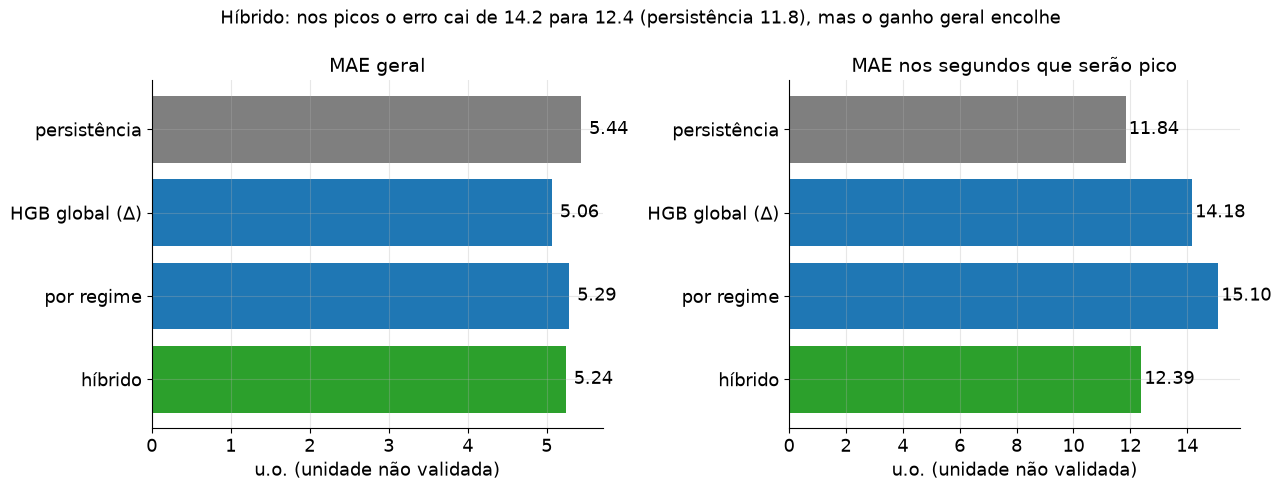

In [25]:
# IC por bootstrap de episódios para MAE_modelo − MAE_persistência (MAE geral e em picos)
mae_fn = lambda te, s: mean_absolute_error(te["y_5"], s)
def mae_pk(te, s):
    pk = (te["y_5"] > te["threshold"]).to_numpy()
    return mean_absolute_error(te["y_5"][pk], s[pk])
sc_reg = {"persistência": {t: ROWS[t]["cons_now"].to_numpy() for t in EXPS}}
for k in ["HGB global (Δ)", "por regime", "híbrido"]:
    sc_reg[k] = {t: REG[t][k] for t in EXPS}
b_all = boot_metric(sc_reg, mae_fn, EXPS); b_pk = boot_metric(sc_reg, mae_pk, EXPS)
rows = []
for k in sc_reg:
    if k == "persistência": continue
    da, dp = b_all[k] - b_all["persistência"], b_pk[k] - b_pk["persistência"]
    rows.append({"modelo": k, "Δ MAE geral vs persist.": da.mean(), "IC95% geral": f"[{ci(da)[0]:+.2f}, {ci(da)[1]:+.2f}]",
                 "Δ MAE em picos": dp.mean(), "IC95% picos": f"[{ci(dp)[0]:+.2f}, {ci(dp)[1]:+.2f}]"})
reg_ci = pd.DataFrame(rows).set_index("modelo"); display(Markdown("**Diferença de MAE contra a persistência (negativo = modelo melhor); IC por bootstrap de episódios**")); display(reg_ci)
RESULTS["regressao_ic"] = reg_ci.reset_index().to_dict(orient="records")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ["persistência", "HGB global (Δ)", "por regime", "híbrido"]
for ax, col, ttl in [(axes[0], "MAE", "MAE geral"), (axes[1], "MAE em picos", "MAE nos segundos que serão pico")]:
    vals = [reg_mean.loc[n, col] for n in order]
    ax.barh(order, vals, color=[C_GRAY if n == "persistência" else (C_GREEN if "híbrido" in n else C_BLUE) for n in order])
    for i, v in enumerate(vals): ax.text(v + 0.1, i, f"{v:.2f}", va="center")
    ax.invert_yaxis(); ax.set_xlabel("u.o. (unidade não validada)"); ax.set_title(ttl)
fig.suptitle(f"Híbrido: nos picos o erro cai de {reg_mean.loc['HGB global (Δ)', 'MAE em picos']:.1f} para {reg_mean.loc['híbrido', 'MAE em picos']:.1f} (persistência {reg_mean.loc['persistência', 'MAE em picos']:.1f}), mas o ganho geral encolhe", fontsize=13)
plt.tight_layout(); plt.show()

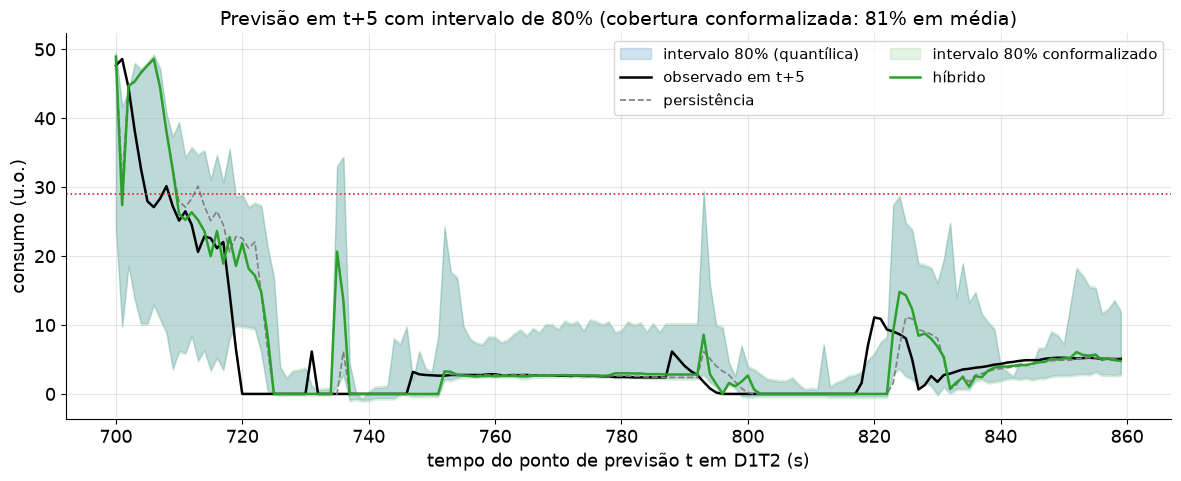

In [26]:
te = ROWS["D1T2"]; pr = REG["D1T2"]; w = te[(te.t_idx >= 700) & (te.t_idx < 860)]; ix = w.index
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(w.t_idx, pr["_lo"][ix], pr["_hi"][ix], color=C_BLUE, alpha=0.2, label="intervalo 80% (quantílica)")
ax.plot(w.t_idx, w.y_5, color="k", lw=1.8, label="observado em t+5")
ax.plot(w.t_idx, w.cons_now, color=C_GRAY, ls="--", lw=1.2, label="persistência")
ax.fill_between(w.t_idx, pr["_lo_c"][ix], pr["_hi_c"][ix], color=C_GREEN, alpha=0.12, label="intervalo 80% conformalizado")
ax.plot(w.t_idx, pr["híbrido"][ix], color=C_GREEN, lw=1.8, label="híbrido")
ax.axhline(w.threshold.iloc[0], color=C_RED, ls=":", lw=1.2)
ax.set_xlabel("tempo do ponto de previsão t em D1T2 (s)"); ax.set_ylabel("consumo (u.o.)"); ax.legend(ncol=2)
ax.set_title(f"Previsão em t+5 com intervalo de 80% (cobertura conformalizada: {cov_mean.loc['_intervalo 80% (conformalizado)', 'cobertura']*100:.0f}% em média)")
plt.tight_layout(); plt.show()

In [14]:
g_, h_, p_ = reg_mean.loc["HGB global (Δ)"], reg_mean.loc["híbrido"], reg_mean.loc["persistência"]
cq, cc = cov_mean.loc["_intervalo 80% (quantílico)"], cov_mean.loc["_intervalo 80% (conformalizado)"]
display(Markdown(f"""**O que concluímos.** O modelo global reduz o MAE geral de {p_['MAE']:.2f} para {g_['MAE']:.2f}, mas **piora nos picos** ({p_['MAE em picos']:.2f} → {g_['MAE em picos']:.2f}). O modelo **por regime não ajudou** (MAE geral {reg_mean.loc['por regime', 'MAE']:.2f}, picos {reg_mean.loc['por regime', 'MAE em picos']:.2f}). O **híbrido** recupera boa parte do erro nos picos ({h_['MAE em picos']:.2f}), mas **ainda não alcança a persistência** nessa região (a diferença de MAE em picos tem IC95% {reg_ci.loc['híbrido', 'IC95% picos']}), e cede parte do ganho geral ({h_['MAE']:.2f}; IC95% da diferença {reg_ci.loc['híbrido', 'IC95% geral']}). É um *trade-off*, não uma solução completa.
O intervalo quantílico bruto cobre só {cq['cobertura']*100:.0f}% dos casos (meta 80%) e apenas {cq['cobertura em picos']*100:.0f}% nos segundos de pico: otimista justamente onde mais importa. A conformalização com validação interna por ensaio sobe a cobertura geral para {cc['cobertura']*100:.0f}% ({cc['cobertura em picos']*100:.0f}% nos picos), com intervalo mais largo ({cq['largura média']:.1f} → {cc['largura média']:.1f} u.o.)."""))

**O que concluímos.** O modelo global reduz o MAE geral de 5.44 para 5.06, mas **piora nos picos** (11.84 → 14.18). O modelo **por regime não ajudou** (MAE geral 5.29, picos 15.10). O **híbrido** recupera boa parte do erro nos picos (12.39), mas **ainda não alcança a persistência** nessa região (a diferença de MAE em picos tem IC95% [+0.27, +0.90]), e cede parte do ganho geral (5.24; IC95% da diferença [-0.26, -0.12]). É um *trade-off*, não uma solução completa.
O intervalo quantílico bruto cobre só 73% dos casos (meta 80%) e apenas 52% nos segundos de pico: otimista justamente onde mais importa. A conformalização com validação interna por ensaio sobe a cobertura geral para 81% (54% nos picos), com intervalo mais largo (15.7 → 16.5 u.o.).

## 5. Explicação: o que precede um pico?

> **Pergunta:** o que acontece nos segundos antes de um pico?  **Entrega:** o padrão descritivo dos sinais antes do pico, quais variáveis o modelo usa, e se regras (Apriori) e regimes (K-Means) contam a mesma história.

Três olhares independentes, uma mensagem:
1. **Assinatura do pico:** média e faixa (25%–75%) dos sinais alinhados no instante de início do episódio (apenas episódios *isolados*: sem pico nos 10 s anteriores).
2. **Taxa de pico por faixa** de cada variável (observada e prevista pelo alerta) e **importância por permutação** por grupo, no ensaio de teste.
3. **Regras e regimes:** quanto dos inícios de pico já estavam "marcados" pela regra do Apriori ou por um regime do K-Means nos segundos anteriores.

Isto descreve o que o *modelo* e os *dados* mostram, **não** o que causa um pico.

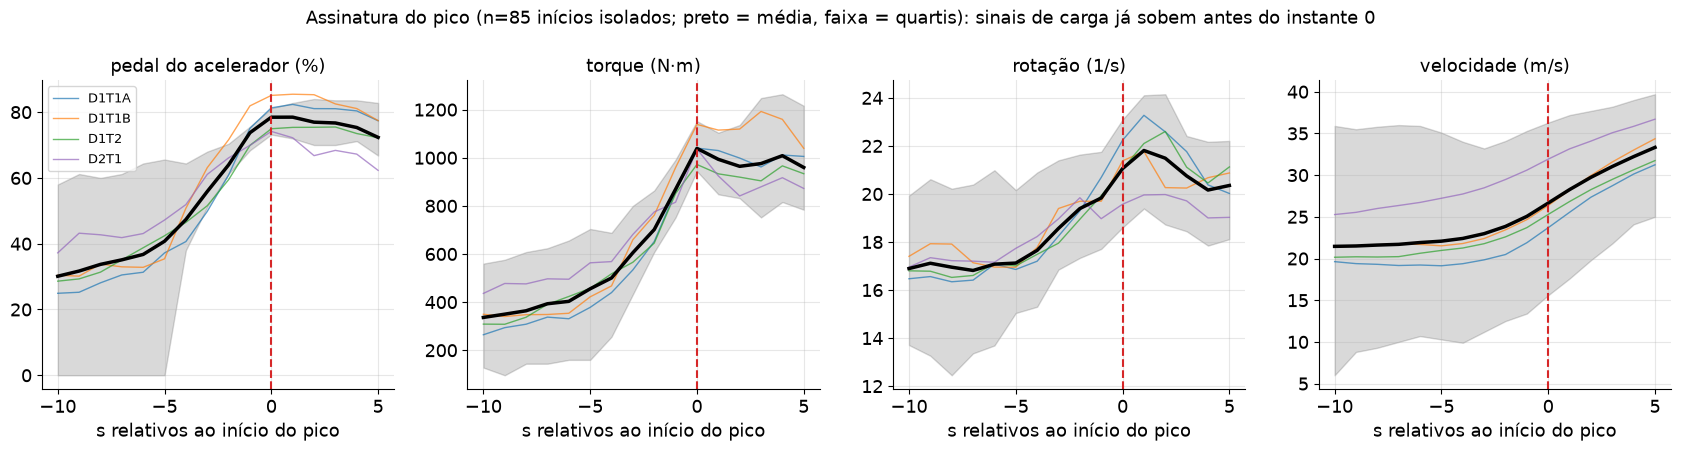

,t-10,t-1,t=0
accelerator_position,30.113,73.751,78.461
engine_torque,336.376,869.082,1038.871
engine_speed,16.896,19.832,21.056
vehicle_speed,21.457,25.053,26.649


In [27]:
SIG_PLOT = [("accelerator_position", "pedal do acelerador (%)"), ("engine_torque", "torque (N·m)"),
            ("engine_speed", "rotação (1/s)"), ("vehicle_speed", "velocidade (m/s)")]
T_AX = np.arange(-10, H + 1)
onsets = {}
for e in EXPS:
    g = full[full.experiment == e].reset_index(drop=True); pn = g.peak_now.to_numpy()
    st = [s for s in np.flatnonzero((pn == 1) & (np.r_[0, pn[:-1]] == 0)) if s >= 10 and s + H < len(g) and not pn[s - 10:s].any()]
    onsets[e] = (g, st)
n_ons = sum(len(v[1]) for v in onsets.values())
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
cols_e = dict(zip(EXPS, ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]))
for ax, (sg, lab) in zip(axes, SIG_PLOT):
    allw = []
    for e, (g, st) in onsets.items():
        W = np.array([g[sg].to_numpy()[s - 10:s + H + 1] for s in st]); allw.append(W)
        ax.plot(T_AX, W.mean(0), color=cols_e[e], lw=1, alpha=0.7, label=e)
    A = np.vstack(allw)
    ax.fill_between(T_AX, np.percentile(A, 25, 0), np.percentile(A, 75, 0), color="k", alpha=0.15)
    ax.plot(T_AX, A.mean(0), color="k", lw=2.5); ax.axvline(0, color=C_RED, ls="--")
    ax.set_title(lab, fontsize=13); ax.set_xlabel("s relativos ao início do pico")
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle(f"Assinatura do pico (n={n_ons} inícios isolados; preto = média, faixa = quartis): sinais de carga já sobem antes do instante 0", fontsize=13)
plt.tight_layout(); plt.show()
RESULTS["n_inicios_isolados"] = int(n_ons)
sig_means = {sg: [float(np.vstack([np.array([g[sg].to_numpy()[s - 10:s + H + 1] for s in st]) for g, st in onsets.values()])[:, i].mean()) for i in (0, 9, 10)] for sg, _ in SIG_PLOT}
RESULTS["assinatura"] = {sg: {"t-10": v[0], "t-1": v[1], "t0": v[2]} for sg, v in sig_means.items()}
display(pd.DataFrame(sig_means, index=["t-10", "t-1", "t=0"]).T)

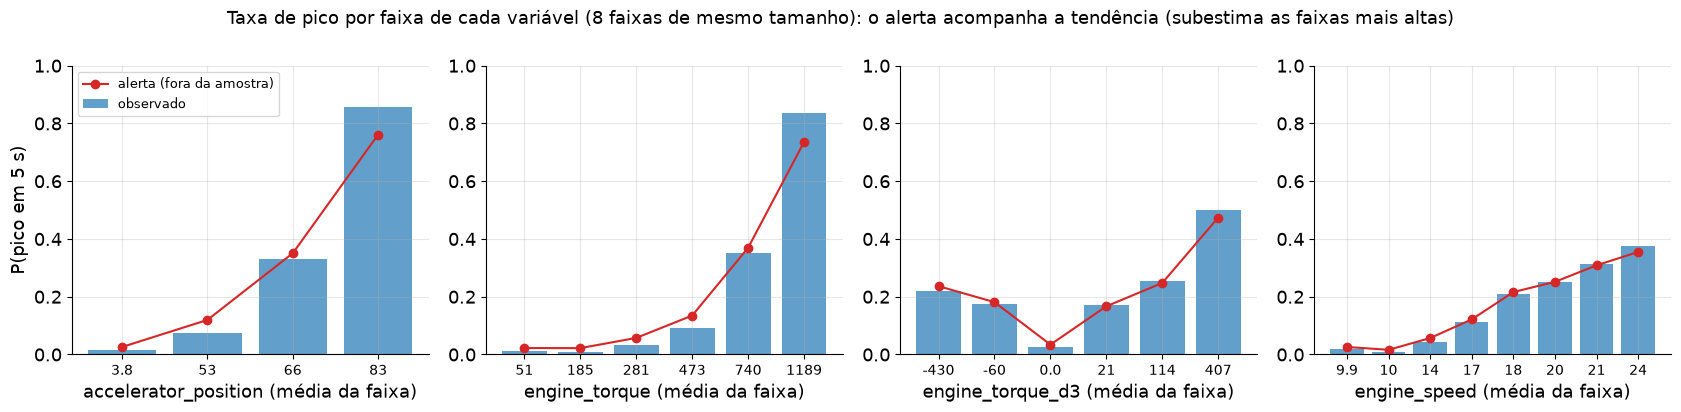

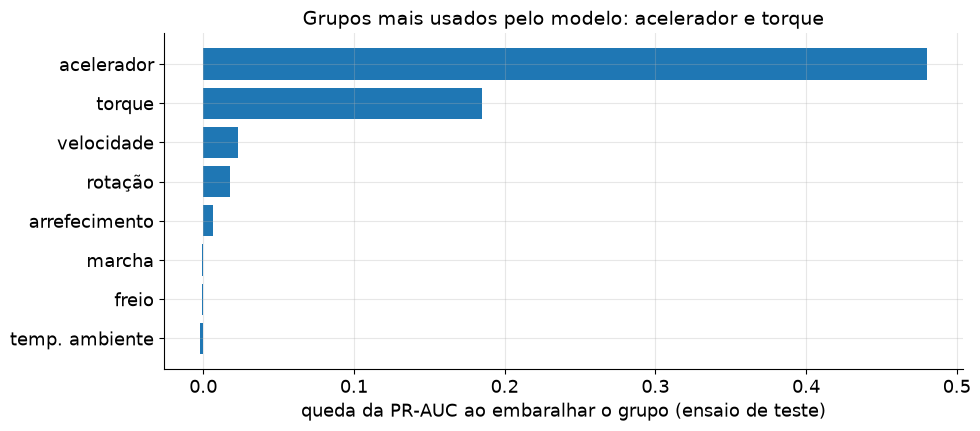

,D1T1A,D1T1B,D1T2,D2T1,média
temp. ambiente,-0.004,0.003,-0.007,0.000,-0.002
freio,-0.000,-0.003,0.000,0.000,-0.001
marcha,0.000,-0.001,-0.002,-0.000,-0.001
arrefecimento,0.009,0.002,0.014,0.000,0.006
rotação,0.012,0.014,0.026,0.020,0.018
velocidade,0.022,0.013,0.019,0.038,0.023
torque,0.074,0.196,0.276,0.193,0.185
acelerador,0.495,0.474,0.438,0.514,0.480


In [28]:
# relação variável × pico: taxa observada por faixa (barras) e média do alerta fora da amostra (linha)
oof_all = pd.concat([ROWS[t].assign(p_cal=ALERT[(t, "OPER")]["p_cal"]) for t in EXPS], ignore_index=True)
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, v in zip(axes, ["accelerator_position", "engine_torque", "engine_torque_d3", "engine_speed"]):
    edges = np.unique(np.quantile(oof_all[v], np.linspace(0, 1, 9)))
    b = pd.cut(oof_all[v], edges, include_lowest=True)
    d_ = oof_all.groupby(b, observed=True).agg(x=(v, "mean"), obs=("peak_next", "mean"), mod=("p_cal", "mean"))
    ax.bar(range(len(d_)), d_["obs"], color=C_BLUE, alpha=0.7, label="observado")
    ax.plot(range(len(d_)), d_["mod"], "o-", color=C_RED, label="alerta (fora da amostra)")
    ax.set_xticks(range(len(d_))); ax.set_xticklabels([f"{x:.0f}" if abs(x) >= 10 else f"{x:.1f}" for x in d_["x"]], fontsize=10)
    ax.set_xlabel(v + " (média da faixa)"); ax.set_ylim(0, 1)
axes[0].set_ylabel("P(pico em 5 s)"); axes[0].legend(fontsize=9)
fig.suptitle("Taxa de pico por faixa de cada variável (8 faixas de mesmo tamanho): o alerta acompanha a tendência (subestima as faixas mais altas)", fontsize=13)
plt.tight_layout(); plt.show()

def perm_groups(model, Xte, y, groups, n=5):
    rng = np.random.default_rng(SEED); base = ap(y, model.predict_proba(Xte)[:, 1]); res = {}
    for g_, cols in groups.items():
        d = []
        for _ in range(n):
            Xp = Xte.copy(); Xp[cols] = Xte[cols].to_numpy()[rng.permutation(len(Xp))]
            d.append(base - ap(y, model.predict_proba(Xp)[:, 1]))
        res[g_] = np.mean(d)
    return res
imp = pd.DataFrame({t: perm_groups(ALERT[(t, "OPER")]["model"], ROWS[t][OPER], ROWS[t]["peak_next"].to_numpy(), GROUPS) for t in EXPS})
imp["média"] = imp.mean(axis=1); imp = imp.sort_values("média")
fig, ax = plt.subplots(figsize=(10, 4.5)); ax.barh(imp.index, imp["média"], color=C_BLUE)
ax.set_xlabel("queda da PR-AUC ao embaralhar o grupo (ensaio de teste)")
ax.set_title(f"Grupos mais usados pelo modelo: {imp.index[-1]} e {imp.index[-2]}")
plt.tight_layout(); plt.show()
RESULTS["importancia"] = {k: float(v) for k, v in imp["média"].items()}
display(imp.round(3))

In [29]:
# ligação com a regra do Apriori e com os regimes do K-Means nos 5 s anteriores aos inícios isolados
Zsc = StandardScaler().fit(data[CL_COLS]); km_all = KMeans(8, n_init=20, random_state=SEED).fit(Zsc.transform(data[CL_COLS]))
data["regime"] = km_all.labels_
risk = data.groupby("regime")["peak_next"].mean().sort_values(ascending=False)
top_regs = list(risk.index[:2]); 
ed_all, ante_all, lift_all, conf_all = best_rule(data)
n_rule = n_reg = n_any = 0; n = 0
for e, (g, st) in onsets.items():
    gv = g.dropna(subset=OPER + CL_COLS).copy()
    act = pd.Series(rule_active(gv, ed_all, ante_all), index=gv.index).reindex(g.index, fill_value=False).to_numpy()
    reg_lab = pd.Series(km_all.predict(Zsc.transform(gv[CL_COLS])), index=gv.index).reindex(g.index).to_numpy()
    for s in st:
        n += 1; a = act[s - H:s].any(); r = np.isin(reg_lab[s - H:s], top_regs).any()
        n_rule += a; n_reg += r; n_any += (a or r)
print("Regra (4 ensaios):", " ∧ ".join(ante_all), f"| lift {lift_all:.2f}, confiança {conf_all:.2f}")
print("Regimes de maior risco:", dict(risk.head(2).round(2)), f"(prevalência geral {data.peak_next.mean():.2f})")
link = {"regra_ativa_5s_antes": n_rule / n, "regime_de_risco_5s_antes": n_reg / n, "qualquer": n_any / n, "n": n}
print({k: round(v, 2) for k, v in link.items()})
RESULTS["ligacao"] = {**link, "regra": " ∧ ".join(ante_all), "lift_regra": lift_all, "conf_regra": conf_all,
                      "risco_regime": float(risk.iloc[0]), "risco_regime2": float(risk.iloc[1])}

Regra (4 ensaios): rot>19.34 ∧ torque_subindo | lift 4.07, confiança 0.68
Regimes de maior risco: {2: np.float64(0.57), 6: np.float64(0.37)} (prevalência geral 0.17)
{'regra_ativa_5s_antes': np.float64(0.62), 'regime_de_risco_5s_antes': np.float64(0.54), 'qualquer': np.float64(0.82), 'n': 85}


In [30]:
sg_ = RESULTS["assinatura"]; L = RESULTS["ligacao"]
display(Markdown(f"""> **Mensagem única.** Os picos de consumo não surgem do nada. Nos {n_ons} inícios isolados, o pedal médio vai de {sg_['accelerator_position']['t-10']:.0f}% (10 s antes) para {sg_['accelerator_position']['t-1']:.0f}% (1 s antes) e o torque de {sg_['engine_torque']['t-10']:.0f} para {sg_['engine_torque']['t-1']:.0f} N·m. A regra do Apriori (`{L['regra']}`, lift {L['lift_regra']:.1f}) esteve ativa nos 5 s anteriores em {L['regra_ativa_5s_antes']*100:.0f}% dos inícios; um dos 2 regimes de maior risco do K-Means (P(pico em 5 s) = {L['risco_regime']:.2f} e {L['risco_regime2']:.2f}, contra {RESULTS['prevalencia_alvo']:.2f} no geral) em {L['regime_de_risco_5s_antes']*100:.0f}%; e pelo menos um dos dois em {L['qualquer']*100:.0f}%. Três olhares independentes apontam o mesmo padrão: **carga alta e crescente antecede o pico**. É descrição, não causa; e nem todo início é anunciado ({(1-L['qualquer'])*100:.0f}% não foram marcados por nenhum dos dois)."""))

> **Mensagem única.** Os picos de consumo não surgem do nada. Nos 85 inícios isolados, o pedal médio vai de 30% (10 s antes) para 74% (1 s antes) e o torque de 336 para 869 N·m. A regra do Apriori (`rot>19.34 ∧ torque_subindo`, lift 4.1) esteve ativa nos 5 s anteriores em 62% dos inícios; um dos 2 regimes de maior risco do K-Means (P(pico em 5 s) = 0.57 e 0.37, contra 0.17 no geral) em 54%; e pelo menos um dos dois em 82%. Três olhares independentes apontam o mesmo padrão: **carga alta e crescente antecede o pico**. É descrição, não causa; e nem todo início é anunciado (18% não foram marcados por nenhum dos dois).

## 6. Robustez: o resultado resiste?

> **Pergunta:** o resultado depende de escolhas arbitrárias (percentil, janela, tipo de divisão)?  **Entrega:** a faixa de resultados em 9 definições de pico e uma validação alternativa.

Três verificações: (i) **sensibilidade** ao percentil de pico (85/90/95) e à janela de antecipação (3/5/10 s); (ii) **validação em blocos de tempo dentro de cada ensaio** (segunda checagem, menos exigente que deixar um ensaio inteiro de fora, porque treino e teste partilham o contexto de condução); (iii) os **intervalos de confiança por episódios** já mostrados nos passos 3 e 4.

prevalência  PR-AUC modelo  PR-AUC persistência  início modelo  início acaso
percentil janela (s)                                                                              
0.85      3                 0.203          0.889                0.654          0.610         0.082
          5                 0.235          0.865                0.627          0.586         0.116
          10                0.297          0.818                0.597          0.556         0.184
0.90      3                 0.145          0.867                0.577          0.599         0.065
          5                 0.171          0.837                0.550          0.588         0.091
          10                0.223          0.753                0.506          0.495         0.147
0.95      3                 0.079          0.784                0.476          0.506         0.040
          5                 0.097          0.752                0.437          0.505         0.057
          10                0.134          0.659                0.381          0.435         0.094

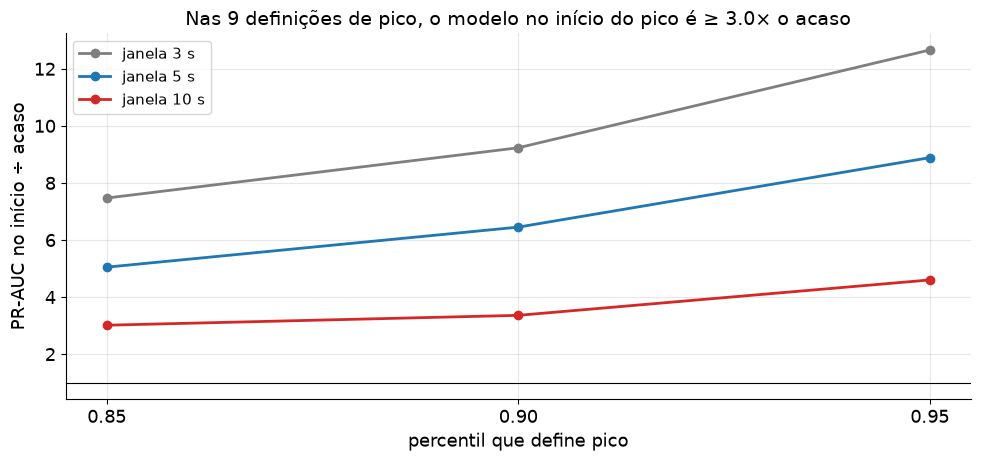

In [31]:
rows = []
for q in [0.85, 0.90, 0.95]:
    for hz in [3, 5, 10]:
        f2 = build_dataset(raw, q=q, horizon=hz)
        d2 = f2.dropna(subset=OPER + ["peak_next"]).reset_index(drop=True); d2["peak_next"] = d2["peak_next"].astype(int)
        for test, tr, te in folds(EXPS, d2):
            s = hgb_clf().fit(tr[OPER], tr["peak_next"]).predict_proba(te[OPER])[:, 1]
            m = te["peak_now"].to_numpy() == 0
            rows.append({"percentil": q, "janela (s)": hz, "teste": test, "prevalência": te["peak_next"].mean(),
                         "PR-AUC modelo": ap(te["peak_next"], s), "PR-AUC persistência": ap(te["peak_next"], te["peak_now"]),
                         "início modelo": ap(te["peak_next"][m], s[m]), "início acaso": te["peak_next"][m].mean()})
sens = pd.DataFrame(rows).groupby(["percentil", "janela (s)"])[["prevalência", "PR-AUC modelo", "PR-AUC persistência", "início modelo", "início acaso"]].mean()
display(sens)
sens["razão início/acaso"] = sens["início modelo"] / sens["início acaso"]
RESULTS["sensibilidade"] = {f"{q}/{h}": {c: float(v) for c, v in r.items()} for (q, h), r in sens.iterrows()}

fig, ax = plt.subplots(figsize=(10, 4.8))
for hz, col in zip([3, 5, 10], [C_GRAY, C_BLUE, C_RED]):
    s_ = sens.xs(hz, level="janela (s)")
    ax.plot(s_.index, s_["início modelo"] / s_["início acaso"], "o-", color=col, lw=2, label=f"janela {hz} s")
ax.axhline(1, color="k", lw=0.8); ax.set_xlabel("percentil que define pico"); ax.set_ylabel("PR-AUC no início ÷ acaso")
ax.set_xticks([0.85, 0.90, 0.95]); ax.legend()
ax.set_title(f"Nas 9 definições de pico, o modelo no início do pico é ≥ {(sens['início modelo'] / sens['início acaso']).min():.1f}× o acaso")
plt.tight_layout(); plt.show()

In [20]:
# validação em blocos de tempo dentro de cada ensaio (5 blocos contíguos, purga de 10 s ao redor do bloco de teste)
PURGE = 10
rows = []; blk_scores = {n: {} for n in ["HGB (OPER)", "persistência"]}
for e in EXPS: ROWS[e]["_blk"] = np.minimum((ROWS[e]["t_idx"] * 5 // (ROWS[e]["t_idx"].max() + 1)).astype(int), 4)
for k in range(5):
    tr_parts, te_parts = [], []
    for e in EXPS:
        r = ROWS[e]; te_m = r["_blk"] == k; lo, hi = r.loc[te_m, "t_idx"].min(), r.loc[te_m, "t_idx"].max()
        tr_parts.append(r[(r.t_idx < lo - PURGE) | (r.t_idx > hi + PURGE)]); te_parts.append(r[te_m])
    tr, te = pd.concat(tr_parts), pd.concat(te_parts)
    s = hgb_clf().fit(tr[OPER], tr["peak_next"]).predict_proba(te[OPER])[:, 1]
    m = te["peak_now"].to_numpy() == 0
    rows.append({"bloco de teste": k + 1, "PR-AUC modelo": ap(te["peak_next"], s), "PR-AUC persistência": ap(te["peak_next"], te["peak_now"]),
                 "início modelo": ap(te["peak_next"][m], s[m]), "início acaso": te["peak_next"][m].mean()})
blk = pd.DataFrame(rows).set_index("bloco de teste"); display(blk); display(blk.mean().to_frame("média").T)
RESULTS["blocos_tempo"] = {c: float(v) for c, v in blk.mean().items()}
RESULTS["loeo_referencia"] = {"PR-AUC modelo": float(ts_mean.loc["HGB (OPER)", "PR-AUC"]), "início modelo": float(ts_mean.loc["HGB (OPER)", "PR-AUC início"])}

,PR-AUC modelo,PR-AUC persistência,início modelo,início acaso
bloco de teste,,,,
1,0.819,0.521,0.577,0.089
2,0.768,0.358,0.589,0.067
3,0.844,0.578,0.624,0.091
4,0.854,0.593,0.541,0.104
5,0.894,0.657,0.609,0.075


,PR-AUC modelo,PR-AUC persistência,início modelo,início acaso
média,0.836,0.542,0.588,0.085


**O que concluímos.** A conclusão sobre o alerta não depende de um percentil ou de uma janela específicos. A validação em blocos de tempo é *menos exigente* que deixar um ensaio inteiro de fora; se ela der números parecidos ou um pouco melhores, isso é esperado, e o número que usamos como referência continua sendo o de ensaio inteiro. Limite honesto: são 4 ensaios, e os ICs de episódio não capturam a variação entre ensaios (cada ensaio tem seu próprio roteiro de condução).

## 7. A temperatura do óleo ajuda?

> **Pergunta:** a medição da temperatura do óleo melhora o alerta e a previsão?  **Entrega:** comparação pareada, com intervalo de confiança, apenas nos 3 ensaios que a possuem.

Só `D1T1A`, `D1T1B` e `D1T2` têm a medição. Mesmas linhas e mesmos folds (teste = um dos três; treino = os outros dois). Comparamos `OPER` contra `OPER + óleo` (temperatura do óleo e `pi_7`, que é óleo ÷ arrefecimento, no mesmo bloco). Avaliamos o **alerta** (PR-AUC e operação com `C_MISS = 3`) e a **regressão híbrida**. Intervalos por bootstrap de episódios.

teste,D1T1A,D1T1B,D1T2,média
variáveis,,,,
sem óleo,0.591,0.598,0.395,0.528
com óleo,0.524,0.591,0.404,0.506


,PR-AUC,PR-AUC início,recall,alarmes falsos/h,antecipados
variáveis,,,,,
sem óleo,0.824,0.528,0.833,64.504,0.902
com óleo,0.814,0.506,0.795,70.318,0.902


Δ PR-AUC início (com óleo − sem óleo): -0.020  IC95% [-0.046, +0.002]


teste,D1T1A,D1T1B,D1T2,média
variáveis,,,,
sem óleo,5.691,5.901,4.855,5.483
com óleo,5.825,5.921,4.896,5.547


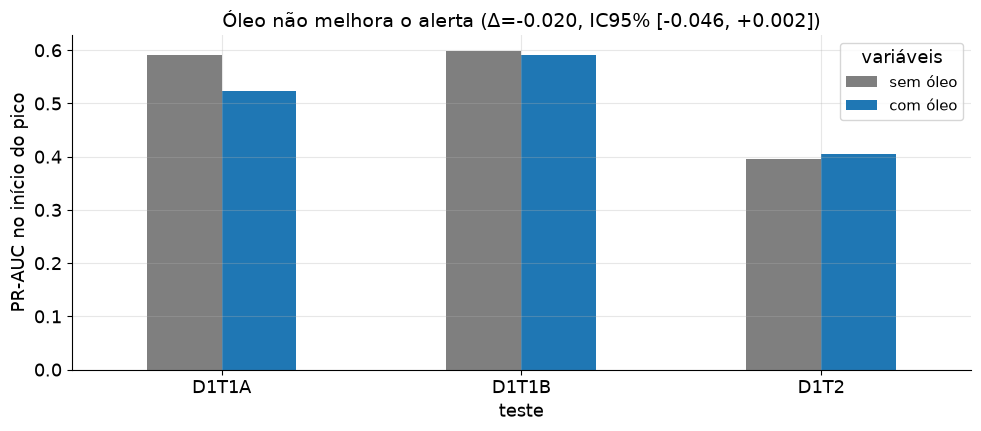

In [32]:
data_oil = data[data.experiment.isin(EXPS_OIL)]
assert data_oil[OIL].notna().all().all()
AL_OIL, SC_OIL, rows = {}, {"sem óleo": {}, "com óleo": {}}, []
for test, tr, te in folds(EXPS_OIL, data_oil):
    for name, cols in [("sem óleo", OPER), ("com óleo", OPER + OIL)]:
        a = fit_alert(tr, te, cols); AL_OIL[(test, name)] = a; SC_OIL[name][test] = a["p_raw"]
        ev = alert_eval(te, a["p_cal"] >= a["thr"][C_MISS])
        rows.append({"teste": test, "variáveis": name, "PR-AUC": ap(te["peak_next"], a["p_raw"]), "PR-AUC início": onset_ap(te, a["p_raw"]),
                     "recall": ev["recall"], "alarmes falsos/h": ev["alarmes falsos/h"], "antecipados": ev["antecipados"]})
oil_al = pd.DataFrame(rows)
display(oil_al.pivot_table(index="variáveis", columns="teste", values="PR-AUC início", sort=False).assign(média=lambda d: d.mean(axis=1)))
display(oil_al.groupby("variáveis", sort=False)[["PR-AUC", "PR-AUC início", "recall", "alarmes falsos/h", "antecipados"]].mean())
b_oil = boot_metric(SC_OIL, lambda te, s: onset_ap(te, s), EXPS_OIL)
d_oil = b_oil["com óleo"] - b_oil["sem óleo"]
print(f"Δ PR-AUC início (com óleo − sem óleo): {d_oil.mean():+.3f}  IC95% [{ci(d_oil)[0]:+.3f}, {ci(d_oil)[1]:+.3f}]")

# regressão híbrida com e sem óleo
rows = []
for test, tr, te in folds(EXPS_OIL, data_oil):
    y = te["y_5"].to_numpy(); base = te["cons_now"].to_numpy(); pk = y > te["threshold"].to_numpy()
    for name, cols in [("sem óleo", REG_COLS), ("com óleo", REG_COLS + OIL)]:
        p = reg_predict_all(tr, te, cols)["híbrido"]
        rows.append({"teste": test, "variáveis": name, "MAE": mean_absolute_error(y, p), "MAE em picos": mean_absolute_error(y[pk], p[pk]),
                     "persistência": mean_absolute_error(y, base)})
oil_reg = pd.DataFrame(rows)
display(oil_reg.pivot_table(index="variáveis", columns="teste", values="MAE", sort=False).assign(média=lambda d: d.mean(axis=1)))
RESULTS["oleo"] = {"alerta": {k: {c: float(v) for c, v in r.items()} for k, r in oil_al.groupby("variáveis")[["PR-AUC", "PR-AUC início", "recall", "alarmes falsos/h", "antecipados"]].mean().iterrows()},
                   "delta_inicio": [float(d_oil.mean()), *ci(d_oil)],
                   "mae_hibrido": {k: float(v) for k, v in oil_reg.groupby("variáveis")["MAE"].mean().items()}}

fig, ax = plt.subplots(figsize=(10, 4.5))
piv = oil_al.pivot_table(index="teste", columns="variáveis", values="PR-AUC início")[["sem óleo", "com óleo"]]
piv.plot.bar(ax=ax, color=[C_GRAY, C_BLUE], rot=0); ax.set_ylabel("PR-AUC no início do pico")
ax.set_title(f"Óleo não melhora o alerta (Δ={d_oil.mean():+.3f}, IC95% [{ci(d_oil)[0]:+.3f}, {ci(d_oil)[1]:+.3f}])")
plt.tight_layout(); plt.show()

**O que concluímos.** Se o intervalo da diferença contém zero, **não há evidência de ganho** ao incluir a temperatura do óleo, nestes 3 ensaios. Isso não prova que ela não importa: são só 3 folds, e a temperatura do óleo sobe com o tempo de ensaio, podendo apenas acompanhar o roteiro de condução (confusão). `pi_7` não acrescenta informação independente, já que é razão de duas temperaturas.

In [22]:
json.dump(RESULTS, open(ROOT / "docs" / "resultados_projeto_alerta.json", "w"), ensure_ascii=False, indent=1, default=float)
pass

## 8. Conclusões

In [34]:
R = RESULTS; a = R["alerta"]["modelo, C_MISS=3"]; ap_ = R["alerta"]["persistência"]; ar = R["alerta"]["regra única (Apriori)"]
display(Markdown(f"""
### Resultados-chave
1. **Dá para avisar antes.** Com um modelo de gradient boosting sobre condições operacionais (sem usar o consumo), o alerta (limiar escolhido só no treino, `C_MISS = 3`) antecipa **{a['antecipados']*100:.0f}%** dos episódios isolados, com mediana de **{a['antecedência mediana (s)']:.0f} s** de antecedência, recall de **{a['recall']*100:.0f}%** e **{a['alarmes falsos/h']:.0f} alarmes falsos por hora**. A persistência antecipa {ap_['antecipados']*100:.0f}% (por construção) e a regra única {ar['antecipados']*100:.0f}%, com recall de {ar['recall']*100:.0f}%. O preço: {a['alarmes falsos/h']:.0f} alarmes falsos/h contra {ap_['alarmes falsos/h']:.0f}/h da persistência e {ar['alarmes falsos/h']:.0f}/h da regra.
2. **Modelos simples bastam.** No início do pico, a PR-AUC é {R['modelos_serie']['HGB (OPER)']['PR-AUC início']:.2f} (gradient boosting `OPER`), {R['modelos_serie']['HGB (janela)']['PR-AUC início']:.2f} (gradient boosting em janela), {R['modelos_serie']['LogReg (janela)']['PR-AUC início']:.2f} (regressão logística) e {R['modelos_serie']['1D-CNN (janela)']['PR-AUC início']:.2f} (1D-CNN), contra {R['modelos_serie']['persistência']['PR-AUC início']:.2f} da persistência. A diferença CNN − gradient boosting é {R['delta_cnn_vs_hgb_inicio'][0]:+.3f} (IC95% [{R['delta_cnn_vs_hgb_inicio'][1]:+.3f}, {R['delta_cnn_vs_hgb_inicio'][2]:+.3f}]).
3. **Regressão: ganho modesto e com ressalva.** O gradient boosting reduz o MAE geral em t+5 de {R['regressao']['persistência']['MAE']:.2f} para {R['regressao']['HGB global (Δ)']['MAE']:.2f} u.o., mas piora nos picos ({R['regressao']['persistência']['MAE em picos']:.2f} → {R['regressao']['HGB global (Δ)']['MAE em picos']:.2f}); o híbrido recupera parte ({R['regressao']['híbrido']['MAE em picos']:.2f}) sem alcançar a persistência.
4. **O que precede o pico é carga alta e crescente**, visível na assinatura dos sinais, nas regras do Apriori e nos regimes do K-Means; a temperatura do óleo não trouxe ganho mensurável (Δ PR-AUC início {R['oleo']['delta_inicio'][0]:+.3f}, IC95% [{R['oleo']['delta_inicio'][1]:+.3f}, {R['oleo']['delta_inicio'][2]:+.3f}]).

### Limitações
* **Unidade do consumo não validada** (sem conversão nem referência do equipamento): MAE e RMSE só valem em u.o.; os alertas, definidos por percentil, não dependem da unidade.
* **Base fixa de 4 ensaios** (3 com óleo): a avaliação sempre deixa um ensaio inteiro de fora e os intervalos são por episódio, mas eles não capturam a variação entre ensaios; as conclusões valem para este conjunto de dados e este tipo de condução, e não se estendem a cenários não representados.
* **Muitos alarmes falsos por hora** ({a['alarmes falsos/h']:.0f}/h com `C_MISS = 3`): o alerta é útil como *aviso*, não como acionamento automático sem filtro; o intervalo de previsão cobre só {R['cobertura']['intervalo 80% (conformalizado)']['cobertura em picos']*100:.0f}% dos picos.
* **Custos de alarme arbitrários** e associações **não causais**: o limiar ideal depende da aplicação real, e "pedal alto antes do pico" descreve, não explica.

### Próximos passos
Validar a unidade com o responsável pelos dados; definir o custo real de um alarme falso; reduzir alarmes falsos (por exemplo exigindo persistência do alerta por 2 s) e melhorar a cobertura do intervalo nos picos; testar o alerta em tempo real (streaming).
"""))


### Resultados-chave
1. **Dá para avisar antes.** Com um modelo de gradient boosting sobre condições operacionais (sem usar o consumo), o alerta (limiar escolhido só no treino, `C_MISS = 3`) antecipa **92%** dos episódios isolados, com mediana de **3 s** de antecedência, recall de **82%** e **56 alarmes falsos por hora**. A persistência antecipa 0% (por construção) e a regra única 63%, com recall de 25%. O preço: 56 alarmes falsos/h contra 17/h da persistência e 38/h da regra.
2. **Modelos simples bastam.** No início do pico, a PR-AUC é 0.59 (gradient boosting `OPER`), 0.55 (gradient boosting em janela), 0.56 (regressão logística) e 0.53 (1D-CNN), contra 0.09 da persistência. A diferença CNN − gradient boosting é -0.057 (IC95% [-0.097, -0.023]).
3. **Regressão: ganho modesto e com ressalva.** O gradient boosting reduz o MAE geral em t+5 de 5.44 para 5.06 u.o., mas piora nos picos (11.84 → 14.18); o híbrido recupera parte (12.39) sem alcançar a persistência.
4. **O que precede o pico é carga alta e crescente**, visível na assinatura dos sinais, nas regras do Apriori e nos regimes do K-Means; a temperatura do óleo não trouxe ganho mensurável (Δ PR-AUC início -0.020, IC95% [-0.046, +0.002]).

### Limitações
* **Unidade do consumo não validada** (sem conversão nem referência do equipamento): MAE e RMSE só valem em u.o.; os alertas, definidos por percentil, não dependem da unidade.
* **Base fixa de 4 ensaios** (3 com óleo): a avaliação sempre deixa um ensaio inteiro de fora e os intervalos são por episódio, mas eles não capturam a variação entre ensaios; as conclusões valem para este conjunto de dados e este tipo de condução, e não se estendem a cenários não representados.
* **Muitos alarmes falsos por hora** (56/h com `C_MISS = 3`): o alerta é útil como *aviso*, não como acionamento automático sem filtro; o intervalo de previsão cobre só 54% dos picos.
* **Custos de alarme arbitrários** e associações **não causais**: o limiar ideal depende da aplicação real, e "pedal alto antes do pico" descreve, não explica.

### Próximos passos
Validar a unidade com o responsável pelos dados; definir o custo real de um alarme falso; reduzir alarmes falsos (por exemplo exigindo persistência do alerta por 2 s) e melhorar a cobertura do intervalo nos picos; testar o alerta em tempo real (streaming).
